In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score

In [2]:
data = pd.read_csv("data.csv")
data.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  str    
 4   City_Tier                        20000 non-null  str    
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities                    

In [4]:
data.describe()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


In [5]:
print(data.isnull().sum())

Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_Miscellaneous    0
d

In [6]:
print(data.columns)

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous'],
      dtype='str')


In [7]:
expense_columns = [
    'Rent',
    'Loan_Repayment',
    'Insurance',
    'Groceries',
    'Transport',
    'Eating_Out',
    'Entertainment',
    'Utilities',
    'Healthcare',
    'Education',
    'Miscellaneous'
]

data['Total_Expenses'] = data[expense_columns].sum(axis=1)

data[['Income', 'Total_Expenses', 'Disposable_Income']].head()

,Income,Total_Expenses,Disposable_Income
0,44637.249636,33371.621929,11265.627707
1,26858.596592,17181.777859,9676.818733
2,50367.605084,36476.154459,13891.450624
3,101455.600247,69837.646632,31617.953615
4,24875.283548,18609.583016,6265.700532


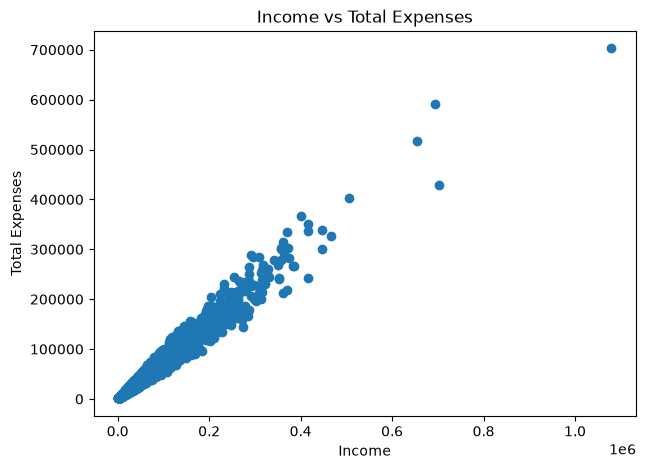

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(data['Income'], data['Total_Expenses'])

plt.xlabel('Income')
plt.ylabel('Total Expenses')
plt.title('Income vs Total Expenses')

plt.show()

In [9]:
X = data[['Income', 'Total_Expenses']]
y = data['Disposable_Income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (16000, 2)
Testing data: (4000, 2)


In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [11]:
y_pred = model.predict(X_test)

print("Actual Savings:")
print(y_test.head())

print("\nPredicted Savings:")
print(y_pred[:5])

Actual Savings:
19134    3737.390333
4981     1707.289863
16643    2327.098982
19117    9847.307391
5306     6808.739180
Name: Disposable_Income, dtype: float64

Predicted Savings:
[3737.39033291 1707.28986305 2327.09898191 9847.30739143 6808.73918026]


In [12]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.7041629440939234e-11


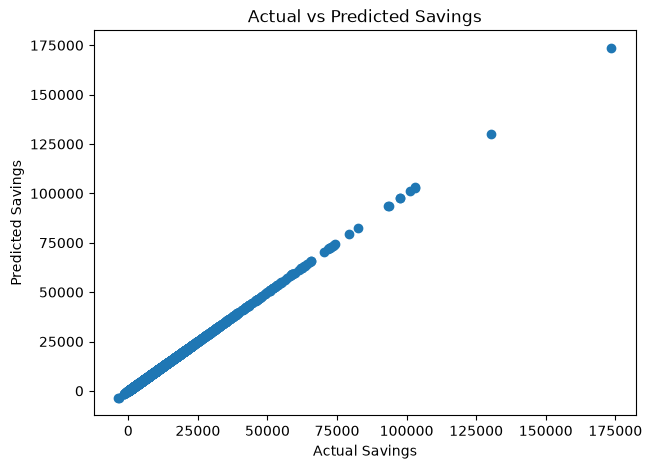

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Savings")
plt.ylabel("Predicted Savings")
plt.title("Actual vs Predicted Savings")

plt.show()

In [14]:
data['Expense_Ratio'] = data['Total_Expenses'] / data['Income']

data[['Income', 'Total_Expenses', 'Expense_Ratio']].head()

,Income,Total_Expenses,Expense_Ratio
0,44637.249636,33371.621929,0.747618
1,26858.596592,17181.777859,0.639712
2,50367.605084,36476.154459,0.724199
3,101455.600247,69837.646632,0.688357
4,24875.283548,18609.583016,0.748115


In [15]:
data['Risk'] = pd.cut(
    data['Expense_Ratio'],
    bins=[0, 0.50, 0.70, 1.0],
    labels=['Low', 'Medium', 'High']
)

data[['Expense_Ratio', 'Risk']].head()

,Expense_Ratio,Risk
0,0.747618,High
1,0.639712,Medium
2,0.724199,High
3,0.688357,Medium
4,0.748115,High


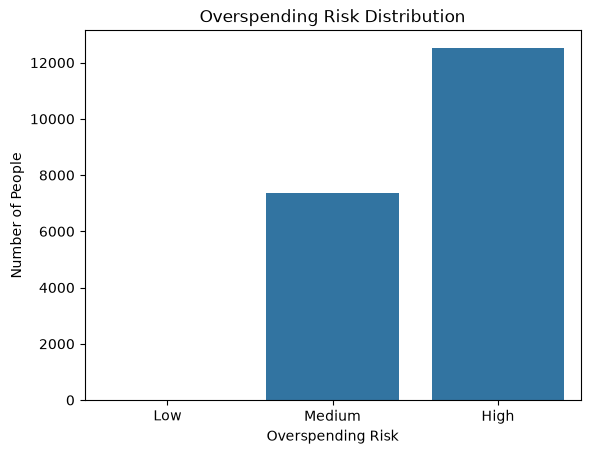

In [16]:
sns.countplot(x='Risk', data=data)

plt.xlabel('Overspending Risk')
plt.ylabel('Number of People')
plt.title('Overspending Risk Distribution')

plt.show()

In [19]:
data['Expense_Ratio'] = data['Total_Expenses'] / data['Income']

data['Risk'] = pd.cut(
    data['Expense_Ratio'],
    bins=[-float('inf'), 0.50, 0.70, float('inf')],
    labels=['Low', 'Medium', 'High']
)

print(data['Risk'].value_counts())

Risk
High      12632
Medium     7363
Low           5
Name: count, dtype: int64


In [20]:
print("Missing Risk values:", data['Risk'].isnull().sum())

Missing Risk values: 0


In [21]:
X = data[['Income', 'Total_Expenses']]
y = data['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16000, 2)
Testing data: (4000, 2)


In [22]:
classifier = DecisionTreeClassifier(random_state=0)

classifier.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [23]:
y_pred_risk = classifier.predict(X_test)

print("Actual Risk:")
print(y_test.head())

print("\nPredicted Risk:")
print(y_pred_risk[:5])

Actual Risk:
19134      High
4981       High
16643      High
19117    Medium
5306       High
Name: Risk, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

Predicted Risk:
['High' 'High' 'High' 'Medium' 'High']


In [24]:
accuracy = accuracy_score(y_test, y_pred_risk)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.9715
